In [ ]:
import os, json, math, time, random
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from functions import preprocess  # retorna (denoised_bgr_224, sobel_224)

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_seed()

# caminhos
ROOT      = Path(".")
DATA_DIR  = ROOT/"dataset"
UNLAB_DIR = ROOT/"imgs"       
SAVE_DIR  = ROOT/"unsup"
(SAVE_DIR/"embeddings").mkdir(parents=True, exist_ok=True)
(SAVE_DIR/"clustering").mkdir(parents=True, exist_ok=True)
(SAVE_DIR/"figs").mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cuda'

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def make_rgb_for_backbone(img_bgr):
    """
    Constrói uma imagem 224x224x3 para extrair embedding:
      1) usa preprocess() -> denoised_bgr_224, sobel_224 (0..255)
      2) converte denoised para RGB
      3) injeta a máscara Sobel no canal G (edge-tint)
    """
    denoised_bgr, sobel = preprocess(img_bgr)     # ambos 224x224
    rgb = cv2.cvtColor(denoised_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    sobel_f = sobel.astype(np.float32)
    # normaliza sobel para 0..255 se necessário
    if sobel_f.max() > 1.5: 
        sobel_f = (sobel_f / 255.0) * 255.0
    # injeta máscara no canal G (mantendo R e B originais)
    rgb[...,1] = np.clip(sobel_f, 0, 255)
    return rgb.astype(np.uint8)  # 0..255, 3 canais


In [4]:
CLASSES = ["buracos", "rachaduras", "boas"]

def list_labeled_images(base=DATA_DIR):
    paths, labels = [], []
    for y, cls in enumerate(CLASSES):
        p = (base/cls)
        for f in sorted(os.listdir(p)):
            if f.lower().endswith((".jpg",".jpeg",".png")):
                paths.append(str(p/f)); labels.append(y)
    return np.array(paths), np.array(labels, dtype=np.int64)

def list_unlabeled_images(base=UNLAB_DIR):
    paths = []
    for f in sorted(os.listdir(base)):
        if f.lower().endswith((".jpg",".jpeg",".png")):
            paths.append(str(base/f))
    return np.array(paths)


In [5]:
class ResNet18Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        m = resnet18(weights=ResNet18_Weights.DEFAULT)
        # remove a FC; fica até o penúltimo (global avgpool -> 512-D)
        self.feature_extractor = nn.Sequential(*list(m.children())[:-1]).eval()
        for p in self.feature_extractor.parameters():
            p.requires_grad = False
        self.feature_extractor.to(DEVICE)

    @torch.no_grad()
    def encode_batch(self, batch_rgb_uint8):  # numpy N,H,W,3 (uint8)
        # para tensor float normalizado ImageNet
        t = torch.stack([to_tensor(x) for x in batch_rgb_uint8]).to(DEVICE)  # N,3,224,224
        f = self.feature_extractor(t).squeeze(-1).squeeze(-2)               # N,512
        return f.cpu().numpy()

encoder = ResNet18Encoder()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\black/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:07<00:00, 6.49MB/s]


In [6]:
def load_img_bgr(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Falha ao ler {path}")
    return img

def compute_embeddings(paths, batch=32, desc="emb"):
    embs = []
    N = len(paths)
    for i in range(0, N, batch):
        batch_paths = paths[i:i+batch]
        batch_rgb = []
        for p in batch_paths:
            img_bgr = load_img_bgr(p)
            rgb224  = make_rgb_for_backbone(img_bgr)  # 224x224x3 uint8
            batch_rgb.append(rgb224)
        feats = encoder.encode_batch(np.stack(batch_rgb, axis=0))
        embs.append(feats)
    return np.concatenate(embs, axis=0)

# Labeled (vamos reutilizar os MESMOS splits do supervisionado, se existirem)
LAB_PATHS, LAB_Y = list_labeled_images()
len(LAB_PATHS), np.bincount(LAB_Y)


(511, array([300, 165,  46]))

In [7]:
SPLITS_JSON = Path("runs/ponto3/splits.json")   # gerado no teu experimento supervisionado
if SPLITS_JSON.exists():
    sp = json.load(open(SPLITS_JSON, "r", encoding="utf-8"))
    idx_tr = np.array(sp["train"]); idx_va = np.array(sp["val"]); idx_te = np.array(sp["test"])
else:
    # fallback: cria splits novos estratificados (se você não tiver o arquivo)
    def stratified_split(y, train=0.7, val=0.15):
        y = np.asarray(y); idx_tr, idx_va, idx_te = [], [], []
        for c in np.unique(y):
            idx = np.where(y==c)[0]; np.random.shuffle(idx)
            n=len(idx); ntr=int(round(train*n)); nva=int(round(val*n))
            idx_tr += idx[:ntr].tolist()
            idx_va += idx[ntr:ntr+nva].tolist()
            idx_te += idx[ntr+nva:].tolist()
        return np.array(idx_tr), np.array(idx_va), np.array(idx_te)
    idx_tr, idx_va, idx_te = stratified_split(LAB_Y, 0.7, 0.15)

print(len(idx_tr), len(idx_va), len(idx_te))


357 77 77


In [8]:
UNLAB_PATHS = list_unlabeled_images(UNLAB_DIR)
print("Unlabeled:", len(UNLAB_PATHS))

# cacheia para acelerar re-runs
EMB_UNLAB_NPY = SAVE_DIR/"embeddings"/"unlabeled_resnet18.npy"
EMB_TRVAL_NPY = SAVE_DIR/"embeddings"/"trainval_resnet18.npy"
EMB_TEST_NPY  = SAVE_DIR/"embeddings"/"test_resnet18.npy"

if EMB_UNLAB_NPY.exists():
    emb_unlab = np.load(EMB_UNLAB_NPY)
else:
    emb_unlab = compute_embeddings(UNLAB_PATHS, batch=64, desc="unlabeled")
    np.save(EMB_UNLAB_NPY, emb_unlab)

# rotulados (separados)
TRVAL_PATHS = LAB_PATHS[np.concatenate([idx_tr, idx_va])]
TRVAL_Y     = LAB_Y[np.concatenate([idx_tr, idx_va])]

TEST_PATHS  = LAB_PATHS[idx_te]
TEST_Y      = LAB_Y[idx_te]

if EMB_TRVAL_NPY.exists():
    emb_trval = np.load(EMB_TRVAL_NPY)
else:
    emb_trval = compute_embeddings(TRVAL_PATHS, batch=64, desc="trainval")
    np.save(EMB_TRVAL_NPY, emb_trval)

if EMB_TEST_NPY.exists():
    emb_test = np.load(EMB_TEST_NPY)
else:
    emb_test = compute_embeddings(TEST_PATHS, batch=64, desc="test")
    np.save(EMB_TEST_NPY, emb_test)

emb_unlab.shape, emb_trval.shape, emb_test.shape


Unlabeled: 4195


((4195, 512, 1), (434, 512, 1), (77, 512, 1))

In [10]:
import numpy as np

def ensure_2d(x, name="emb"):
    x = np.asarray(x)
    if x.ndim > 2:                      # ex.: (N, 512, 1) ou (N, 512, 1, 1)
        print(f"[warn] {name} shape {x.shape} -> flatten")
        x = x.reshape(x.shape[0], -1)   # vira (N, D)
    elif x.ndim == 1:                   # ex.: (D,)
        x = x.reshape(1, -1)
    if not np.isfinite(x).all():
        raise ValueError(f"{name} tem NaN/Inf")
    return x.astype(np.float32, copy=False)

emb_unlab = ensure_2d(emb_unlab, "emb_unlab")
emb_trval = ensure_2d(emb_trval, "emb_trval")   # se for usar depois
emb_test  = ensure_2d(emb_test,  "emb_test")    # se for avaliar depois

from sklearn.preprocessing import normalize
emb_unlab_n = normalize(emb_unlab, norm="l2")


[warn] emb_unlab shape (4195, 512, 1) -> flatten
[warn] emb_trval shape (434, 512, 1) -> flatten
[warn] emb_test shape (77, 512, 1) -> flatten


In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

# Normaliza L2 (ajuda KMeans em espaço de embeddings)
emb_unlab_n = normalize(emb_unlab, norm="l2")
kmeans = KMeans(n_clusters=3, n_init=20, random_state=SEED)
kmeans.fit(emb_unlab_n)

# salva
import joblib, pandas as pd
joblib.dump(kmeans, SAVE_DIR/"clustering"/"kmeans_k3.pkl")

# registra clusters das não rotuladas
unlab_clusters = kmeans.predict(emb_unlab_n)
pd.DataFrame({"path": UNLAB_PATHS, "cluster": unlab_clusters}).to_csv(
    SAVE_DIR/"clustering"/"labels_unlabeled.csv", index=False
)

np.bincount(unlab_clusters)


array([1550, 1385, 1260])

In [12]:
# mapeia pelo voto majoritário em train+val
emb_trval_n = normalize(emb_trval, norm="l2")
cl_trval = kmeans.predict(emb_trval_n)

mapping = {}
for c in range(3):
    idx = np.where(cl_trval == c)[0]
    if len(idx)==0:
        mapping[c] = int(np.argmax(np.bincount(TRVAL_Y)))  # fallback: classe mais comum
    else:
        maj = int(np.argmax(np.bincount(TRVAL_Y[idx])))
        mapping[c] = maj

print("cluster -> classe:", mapping)
json.dump(mapping, open(SAVE_DIR/"clustering"/"mapping.json","w"))


cluster -> classe: {0: 2, 1: 0, 2: 0}


In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score

emb_test_n = normalize(emb_test, norm="l2")
cl_test = kmeans.predict(emb_test_n)
y_pred = np.array([mapping[c] for c in cl_test], dtype=np.int64)

acc = accuracy_score(TEST_Y, y_pred)
cm  = confusion_matrix(TEST_Y, y_pred, labels=[0,1,2])
print("Acurácia (teste):", acc)
print("Matriz de confusão:\n", cm)

np.save(SAVE_DIR/"clustering"/"cm_kmeans.npy", cm)
with open(SAVE_DIR/"clustering"/"metrics_kmeans.json","w") as f:
    json.dump({"test_acc": float(acc), "mapping": mapping}, f, indent=2)


Acurácia (teste): 0.5844155844155844
Matriz de confusão:
 [[43  0  2]
 [21  0  4]
 [ 5  0  2]]


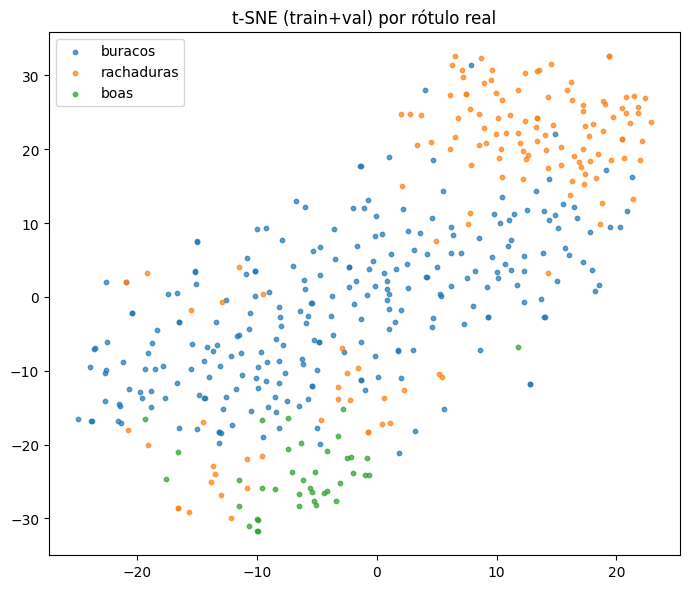

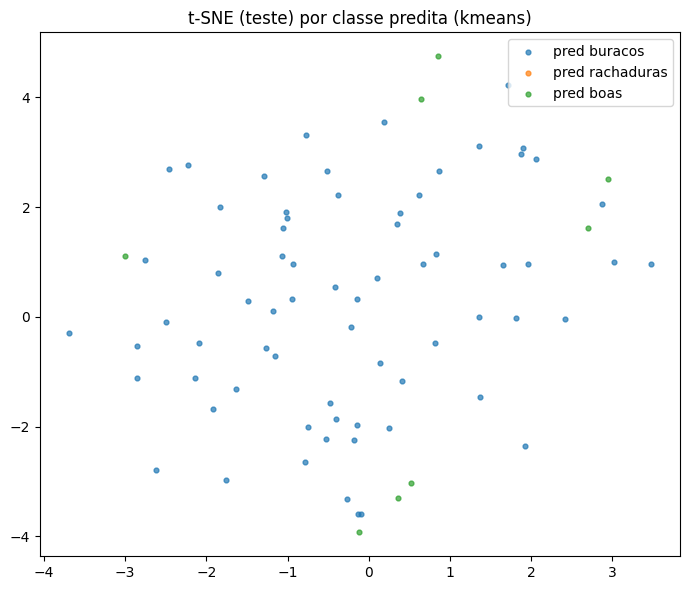

In [14]:
# t-SNE dos embeddings de train+val (cor por CLASSE real)
from sklearn.manifold import TSNE
X2 = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca").fit_transform(emb_trval)
plt.figure(figsize=(7,6))
for c, name in enumerate(CLASSES):
    idx = np.where(TRVAL_Y==c)[0]
    plt.scatter(X2[idx,0], X2[idx,1], s=10, label=name, alpha=0.7)
plt.legend(); plt.title("t-SNE (train+val) por rótulo real")
plt.tight_layout(); plt.savefig(SAVE_DIR/"figs"/"tsne_labels.png", dpi=160)
plt.show()

# t-SNE do teste (cor por CLUSTER -> classe predita)
X2t = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca").fit_transform(emb_test)
plt.figure(figsize=(7,6))
for c, name in enumerate(CLASSES):
    idx = np.where(y_pred==c)[0]
    plt.scatter(X2t[idx,0], X2t[idx,1], s=12, label=f"pred {name}", alpha=0.7)
plt.legend(); plt.title("t-SNE (teste) por classe predita (kmeans)")
plt.tight_layout(); plt.savefig(SAVE_DIR/"figs"/"tsne_pred_test.png", dpi=160)
plt.show()


Total de não rotuladas: 4195

Contagem por cluster:
cluster
0    1550
1    1385
2    1260
Name: count, dtype: int64
Salvo em: unsup\figs\samples_cluster0.png


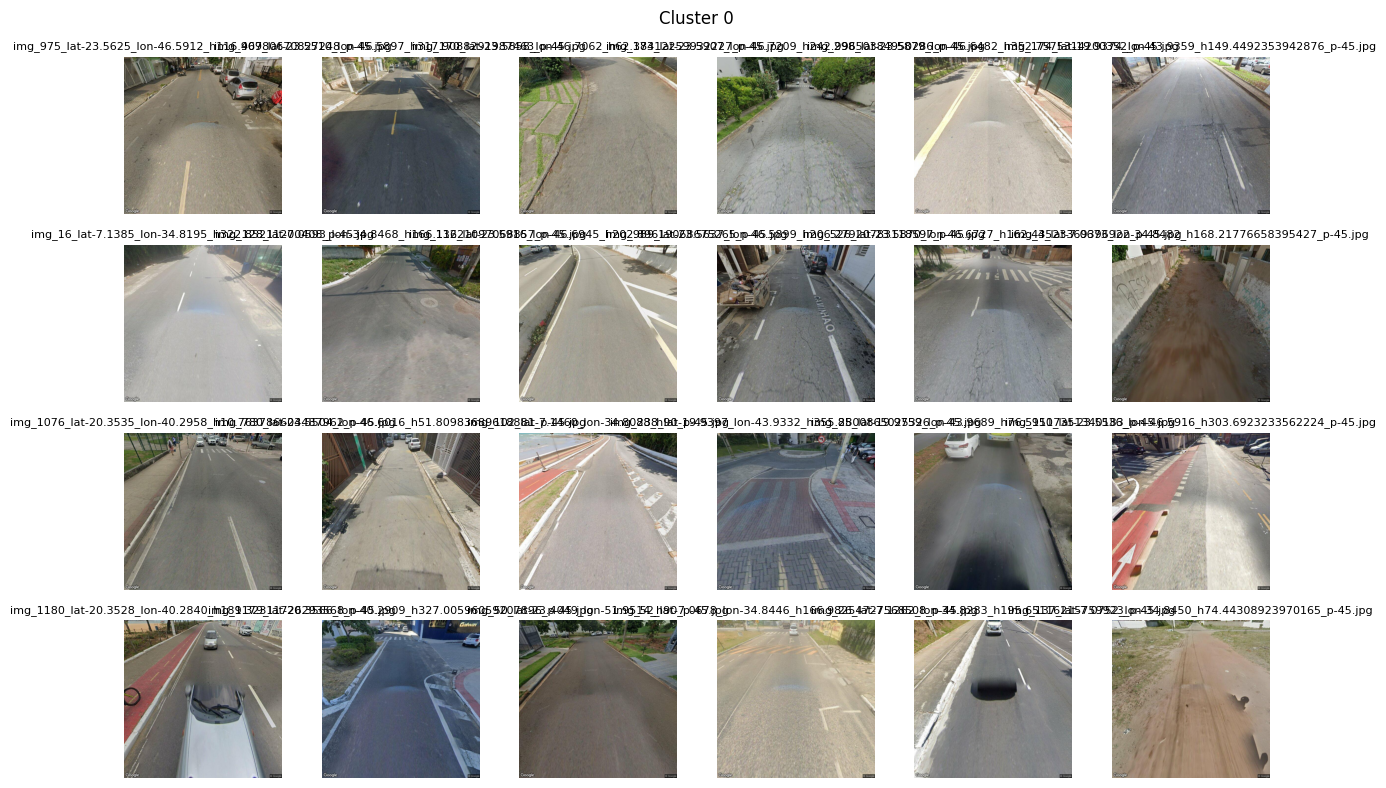

Salvo em: unsup\figs\samples_cluster1.png


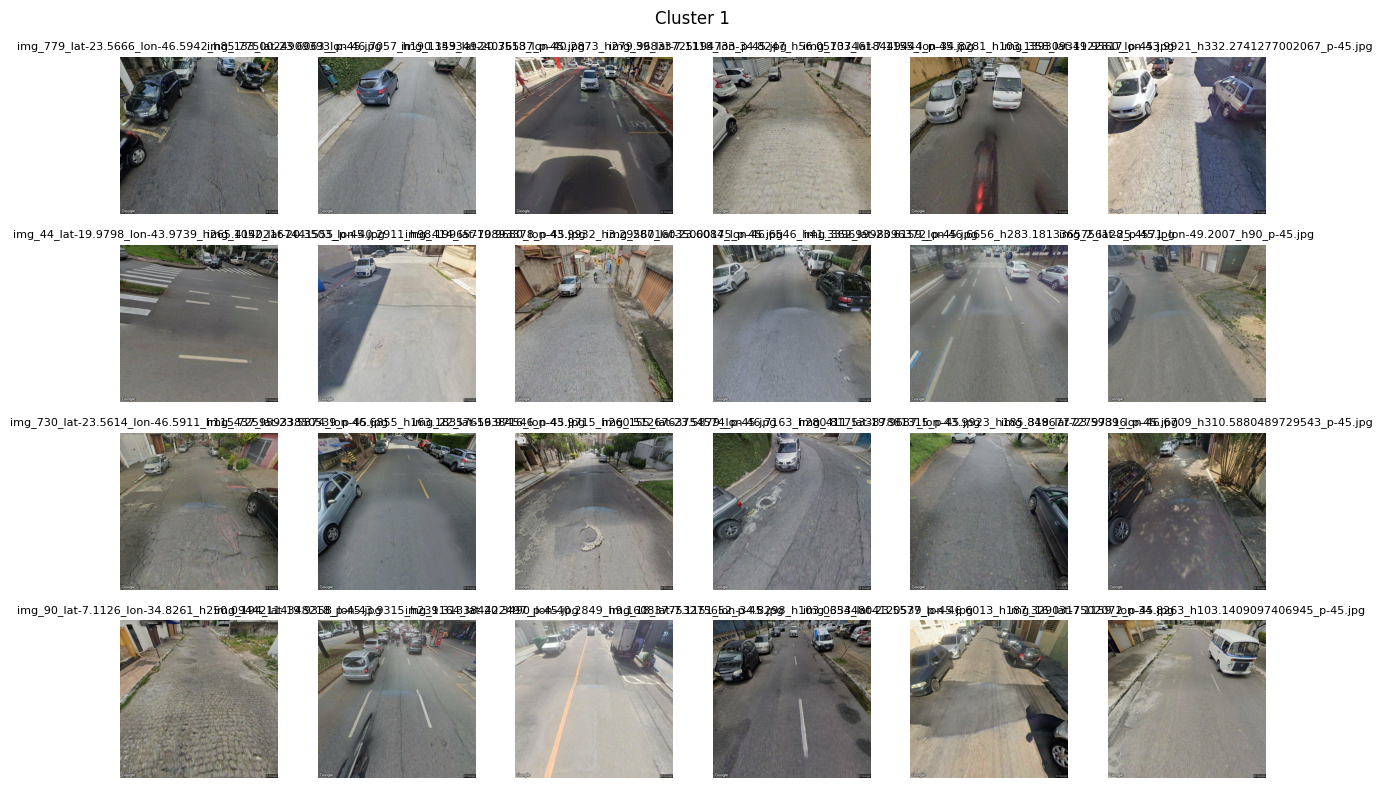

Salvo em: unsup\figs\samples_cluster2.png


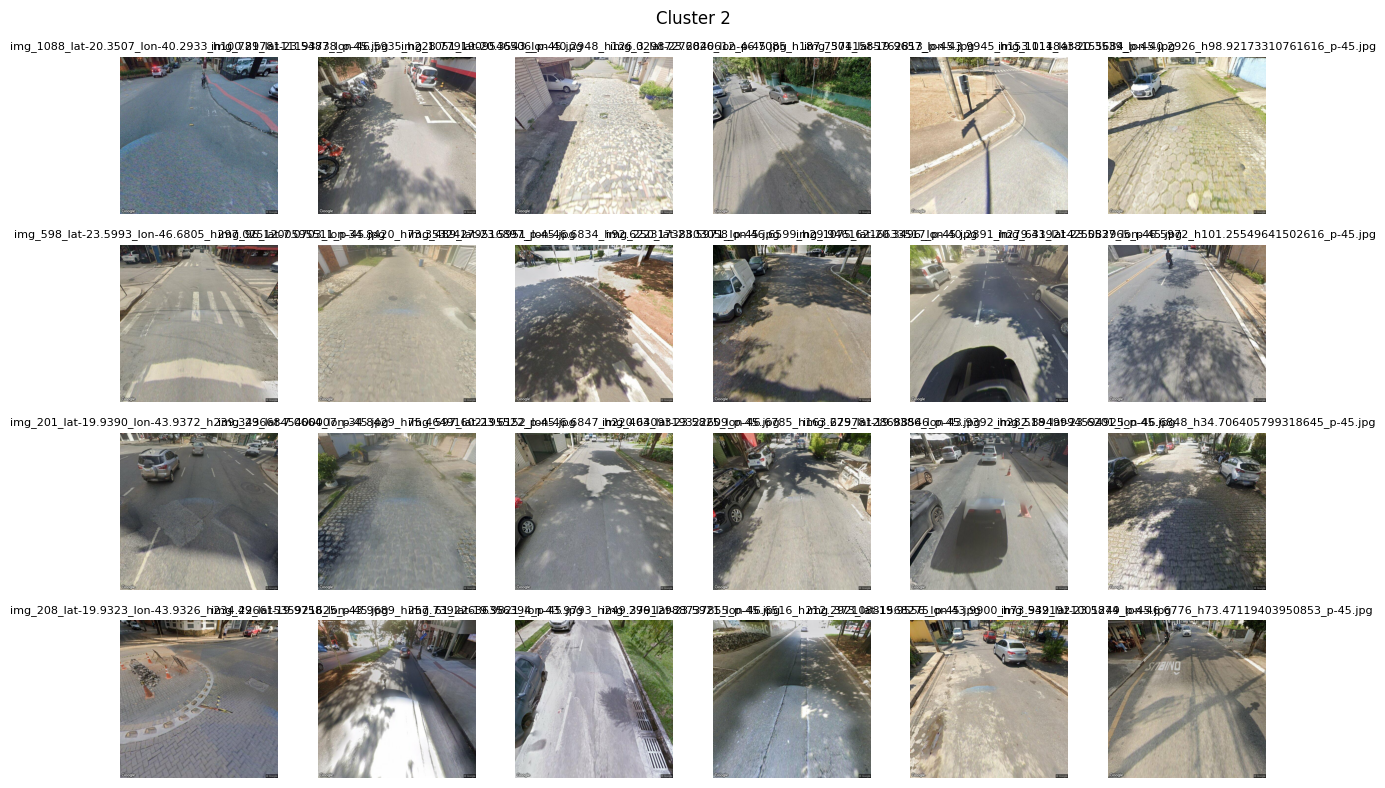

In [16]:
from pathlib import Path
import pandas as pd, numpy as np, cv2, matplotlib.pyplot as plt
import joblib, json, os

SAVE_DIR = Path("unsup")  # ajuste se necessário

# Carrega resultados do KMeans
df_unlab = pd.read_csv(SAVE_DIR/"clustering"/"labels_unlabeled.csv")
kmeans   = joblib.load(SAVE_DIR/"clustering"/"kmeans_k3.pkl")

print("Total de não rotuladas:", len(df_unlab))
print("\nContagem por cluster:")
print(df_unlab["cluster"].value_counts().sort_index())

# Função de grade visual
def show_grid(img_paths, rows=4, cols=6, title="", outpath=None):
    plt.figure(figsize=(cols*2, rows*2))
    for i, p in enumerate(img_paths[:rows*cols]):
        img_bgr = cv2.imread(p)
        if img_bgr is None: continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(img_rgb); ax.axis("off")
        ax.set_title(os.path.basename(p), fontsize=8)
    plt.suptitle(title)
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=160)
        print("Salvo em:", outpath)
    plt.show()

# Amostras aleatórias de cada cluster (24 imagens por cluster)
for c in sorted(df_unlab["cluster"].unique()):
    amostras = df_unlab[df_unlab["cluster"]==c]["path"].sample(min(24, (df_unlab["cluster"]==c).sum()), random_state=42).tolist()
    show_grid(amostras, rows=4, cols=6, title=f"Cluster {c}", outpath=SAVE_DIR/"figs"/f"samples_cluster{c}.png")


In [15]:
# distâncias ao centróide
centroids = kmeans.cluster_centers_
dists = np.linalg.norm(emb_unlab_n - centroids[unlab_clusters], axis=1)

# pega top 40% mais próximos por cluster
keep_idx = []
for c in range(3):
    idx = np.where(unlab_clusters==c)[0]
    if len(idx)==0: continue
    k = max(1, int(0.4*len(idx)))
    sel = idx[np.argsort(dists[idx])[:k]]
    keep_idx.extend(sel)
keep_idx = np.array(keep_idx)

pseudo_paths  = UNLAB_PATHS[keep_idx]
pseudo_labels = np.array([mapping[c] for c in unlab_clusters[keep_idx]], dtype=np.int64)

# salva lista para posterior re-treino supervisionado (com peso menor, se quiser)
import pandas as pd
pd.DataFrame({"path": pseudo_paths, "label": pseudo_labels}).to_csv(
    SAVE_DIR/"clustering"/"pseudo_selected.csv", index=False
)
len(pseudo_paths), np.bincount(pseudo_labels, minlength=3)


(1678, array([1058,    0,  620]))